In [365]:
# %pip install pandas pyarrow scikit-learn pymorphy3 joblib

In [448]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
import joblib

import re
from pymorphy3 import MorphAnalyzer
import emoji

from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

# импортируем трансформеры
import transformers
import warnings
warnings.filterwarnings('ignore')

import torch
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
import torchutils as tu
from torchmetrics.classification import BinaryAccuracy

In [367]:
# Загрузка данных
df = pd.read_feather('data/tg_channels.feather')

print(df.head())

                               url                      date  \
0  https://t.me/s/russianmoda/5961 2023-09-17 17:09:06+00:00   
1  https://t.me/s/russianmoda/5957 2023-09-17 12:09:06+00:00   
2  https://t.me/s/russianmoda/5951 2023-09-17 06:09:06+00:00   
3  https://t.me/s/russianmoda/5939 2023-09-16 17:09:06+00:00   
4  https://t.me/s/russianmoda/5935 2023-09-16 12:09:06+00:00   

                                             content label  
0  Широкие бедра всегда считались роскошью и прид...  мода  
1  Не знаю как у вас, но у меня ни одна осень не ...  мода  
2  Осенью настроение немножко ухудшается. Этому с...  мода  
3  Кардиган очень коварен в стилизации, поэтому е...  мода  
4  Трикотажные костюмы часто ассоциируются с брюк...  мода  


In [368]:
df.head()

,url,date,content,label
0,https://t.me/s/russianmoda/5961,2023-09-17 17:09:06+00:00,Широкие бедра всегда считались роскошью и прид...,мода
1,https://t.me/s/russianmoda/5957,2023-09-17 12:09:06+00:00,"Не знаю как у вас, но у меня ни одна осень не ...",мода
2,https://t.me/s/russianmoda/5951,2023-09-17 06:09:06+00:00,Осенью настроение немножко ухудшается. Этому с...,мода
3,https://t.me/s/russianmoda/5939,2023-09-16 17:09:06+00:00,"Кардиган очень коварен в стилизации, поэтому е...",мода
4,https://t.me/s/russianmoda/5935,2023-09-16 12:09:06+00:00,Трикотажные костюмы часто ассоциируются с брюк...,мода


In [369]:
df.shape

(2900, 4)

In [370]:
df['label'].value_counts(normalize=True)

label
мода          0.206897
технологии    0.206897
финансы       0.206897
крипта        0.206897
спорт         0.172414
Name: proportion, dtype: float64

In [371]:
df.describe()

,url,date,content,label
count,2900,2900,2852,2900
unique,2900,NaN,2779,5
top,https://t.me/s/russianmoda/5961,NaN,"🤯 СКА проиграл ""Торпедо"" в матче КХЛВстреча за...",мода
freq,1,NaN,3,600
mean,NaN,2023-08-14 12:46:32.431379200+00:00,NaN,NaN
min,NaN,2022-11-21 15:46:54+00:00,NaN,NaN
25%,NaN,2023-07-28 15:07:17.249999872+00:00,NaN,NaN
50%,NaN,2023-09-02 12:25:26.500000+00:00,NaN,NaN
75%,NaN,2023-09-13 16:31:23.750000128+00:00,NaN,NaN
max,NaN,2023-09-17 20:17:38+00:00,NaN,NaN


In [372]:
df['content'][1000]

'Евгений Рылов не собирается прогибаться под требования МОК: олимпийский чемпион заявил, что откажется подписывать декларации для участия в ОИ."В МОК могут выдвинуть условия подписать декларацию, если мне такое предложат, я точно откажусь", - сказал пловец.Достойное решение 👏🏻'

In [373]:
morph = MorphAnalyzer()

import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('russian'))

def clean_text_v2(text):
    # 1. Удаляем ссылки (t.me, http, https)
    text = re.sub(r'https?://\S+|www\.\S+|t\.me/\S+', ' ', text)

    text = re.sub(r'@\S+', ' ', text)
    
    # 2. Удаляем ВСЁ, кроме букв (русских и английских) и пробелов
    # Это очистит эмодзи (👏🏻, 🏆), пунктуацию и цифры
    text = re.sub(r'[^а-яА-Яa-zA-Z\s]', ' ', text)
    
    # 3. Приводим к нижнему регистру и убираем лишние пробелы
    text = text.lower().strip()
    
    # 4. Лемматизация (приведение к начальной форме)
    # Разбиваем текст на слова, лемматизируем и оставляем слова длиннее 2 символов
    # Лемматизация + удаление стоп-слов + фильтрация по длине
    tokens = [
        morph.parse(word)[0].normal_form 
        for word in text.split() 
        if word not in stop_words and len(word) > 2
    ]
    return " ".join(tokens)

# Проверка на вашем примере:
example = df['content'][100]
print(f"Результат очистки:\n{clean_text_v2(example)}")

Результат очистки:
самый стильный образ пиджак созадть сочетать платье комбинация комбинация считаться база гардероб помимо пиджак быть отлично смотреться рубашка свитер love republic gate namelazz


[nltk_data] Downloading package stopwords to /home/andre/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [374]:
df.isna().mean()

url        0.000000
date       0.000000
content    0.016552
label      0.000000
dtype: float64

In [375]:
cleaned_content = df['content'].fillna("").apply(clean_text_v2)
empty_after_clean = cleaned_content.isin(["", None])
print(f"Станут пустыми после очистки: {empty_after_clean.sum()}")

Станут пустыми после очистки: 49


если контента нет, то эти строки не информативны так как невозможно на основании пустоты предсказать тему

In [376]:
df = df.dropna(subset=['content'])

In [377]:
df.isna().mean()

url        0.0
date       0.0
content    0.0
label      0.0
dtype: float64

### BaseLine на LogisticRegression

In [378]:
df['label'].value_counts(normalize=True)

label
мода          0.209677
технологии    0.206522
финансы       0.204418
крипта        0.204418
спорт         0.174965
Name: proportion, dtype: float64

In [379]:
print("Начинаю очистку датасета...")
df['cleaned_content'] = df['content'].apply(clean_text_v2)
print("Очистка завершена!")

Начинаю очистку датасета...
Очистка завершена!


In [380]:
print(df['content'][101])
print(df['cleaned_content'][101])

Сейчас актуальны и укороченные, и удлиненные модели пиджаков. Конечно же, помним и про классику. У брендов ниже представлены самые необычные варианты, из которых вы точно выберете свой идеальный пиджак!SHI SHISTUDIO 29Nude StoryLichi
актуальный укоротить удлинённый модель пиджак помнить классика бренд ниже представить самый необычный вариант который точно выбрать свой идеальный пиджак shi shistudio nude storylichi


In [381]:
mapping = {'мода': 0, 
           'технологии': 1, 
           'финансы': 2, 
           'крипта': 3, 
           'спорт': 4}
df['label_num'] = df['label'].map(mapping)

In [382]:
df_lr = df[df['cleaned_content'].str.split().str.len() >= 3].copy()

In [383]:
df

,url,date,content,label,cleaned_content,label_num
0,https://t.me/s/russianmoda/5961,2023-09-17 17:09:06+00:00,Широкие бедра всегда считались роскошью и прид...,мода,широкий бедро считаться роскошь придавать похо...,0
1,https://t.me/s/russianmoda/5957,2023-09-17 12:09:06+00:00,"Не знаю как у вас, но у меня ни одна осень не ...",мода,знать один осень обходиться кожаный куртка сез...,0
2,https://t.me/s/russianmoda/5951,2023-09-17 06:09:06+00:00,Осенью настроение немножко ухудшается. Этому с...,мода,осень настроение немножко ухудшаться этот спос...,0
3,https://t.me/s/russianmoda/5939,2023-09-16 17:09:06+00:00,"Кардиган очень коварен в стилизации, поэтому е...",мода,кардиган очень коварный стилизация поэтому нез...,0
4,https://t.me/s/russianmoda/5935,2023-09-16 12:09:06+00:00,Трикотажные костюмы часто ассоциируются с брюк...,мода,трикотажный костюм часто ассоциироваться брюки...,0
...,...,...,...,...,...,...
2895,https://t.me/s/crypto_dancing/848,2023-06-29 17:30:58+00:00,Mastercard планирует создать магазин для блокч...,крипта,mastercard планировать создать магазин блокчей...,3
2896,https://t.me/s/crypto_dancing/847,2023-06-29 13:01:21+00:00,Hang Seng Investment Management рассматривает ...,крипта,hang seng investment management рассматривать ...,3
2897,https://t.me/s/crypto_dancing/846,2023-06-28 16:31:03+00:00,Аналитик Bloomberg оценил шансы BlackRock на з...,крипта,аналитик bloomberg оценить шанс blackrock запу...,3
2898,https://t.me/s/crypto_dancing/845,2023-06-28 12:00:47+00:00,Профессия блокчейн-разработчика✏️ ♾ Блокчейн-п...,крипта,профессия блокчейн разработчик блокчейн проект...,3


In [384]:
X_train, X_valid, y_train, y_valid = train_test_split(df_lr['cleaned_content'], df_lr['label_num'], test_size=0.25, random_state=42, stratify=df_lr['label_num'])
X_valid, X_test, y_valid, y_test = train_test_split(X_valid, y_valid, test_size=0.35, random_state=42, stratify=y_valid)
print(f"Обучение (Train): {len(X_train)} строк")
print(f"Валидация (Val):   {len(X_valid)} строк")
print(f"Тест (Test):       {len(X_test)} строк")

Обучение (Train): 2135 строк
Валидация (Val):   462 строк
Тест (Test):       250 строк


In [385]:
X_train_lr = X_train.copy()
X_valid_lr = X_valid.copy()
X_test_lr = X_test.copy()
y_train_lr = y_train.copy()
y_valid_lr = y_valid.copy()
y_test_lr = y_test.copy()

In [386]:
# print("Начинаю очистку датасета...")
# X_train_lr = X_train.apply(clean_text_v2)
# X_valid_lr = X_valid.apply(clean_text_v2)
# X_test_lr = X_test.apply(clean_text_v2)


# # Оставляем только те строки, где есть хотя бы 3 слова (не пустые)
# mask = X_train_lr.str.split().str.len() >= 3
# maskv = X_valid_lr.str.split().str.len() >= 3
# maskt = X_test_lr.str.split().str.len() >= 3

# X_train_lr, y_train_lr = X_train_lr[mask], y_train[mask]
# X_valid_lr, y_valid_lr = X_valid_lr[maskv], y_valid[maskv]
# X_test_lr, y_test_lr = X_test_lr[maskt], y_test[maskt]


# print("Очистка завершена!")

In [387]:
print(X_train_lr)

1591    человек глупый нейронка распознать объект очев...
421     клип кайлить миноуга отдельный вид искусство в...
1811    калифорния подать суд крупный нефтяной компани...
1437    роботакси cruise остин личный опыт вчера прока...
1666    текст видео уметь ведьма блер качество выше пр...
                              ...                        
569     съёмка такой милый розочка пояс тренч получить...
706     россиянин магомед победить украинец блесецкий ...
1503    авторский право распространяться произведение ...
2258    важный момент думать говорить прошлое экстренн...
684     тоттенхэма гореть выиграть самый поздний камбэ...
Name: cleaned_content, Length: 2135, dtype: str


In [388]:
print(y_train_lr)

1591    1
421     0
1811    2
1437    1
1666    1
       ..
569     0
706     4
1503    1
2258    2
684     4
Name: label_num, Length: 2135, dtype: int64


In [389]:
from collections import Counter

# Собираем все слова из тренировочной выборки
all_words = ' '.join(X_train_lr).split()
word_counts = Counter(all_words)

print(f"Всего уникальных слов: {len(word_counts)}")

# Смотрим, сколько слов встречаются хотя бы 2 или 3 раза
min_freq = 3
words_above_min = [w for w, c in word_counts.items() if c >= min_freq]
print(f"Слов с частотой >= {min_freq}: {len(words_above_min)}")

Всего уникальных слов: 18293
Слов с частотой >= 3: 6678


In [390]:
tfidf = TfidfVectorizer(max_features=6655, ngram_range=(1, 2))

X_train_tfidf = tfidf.fit_transform(X_train_lr)
X_valid_tfidf = tfidf.transform(X_valid_lr)
X_test_tfidf = tfidf.transform(X_test_lr)

In [391]:
model_logreg = LogisticRegression(C=15, max_iter=1000, random_state=42)
model_logreg.fit(X_train_tfidf, y_train_lr)

# Предсказываем на валидации
y_pred_val = model_logreg.predict(X_valid_tfidf)

# Смотрим результат
print(f"Accuracy на валидации: {accuracy_score(y_valid_lr, y_pred_val):.4f}")
print("\nОтчет по классам:")
print(classification_report(y_valid_lr, y_pred_val))
accuracy_logreg_valid = accuracy_score(y_valid_lr, y_pred_val)
macro_f1_logreg_valid = f1_score(y_valid_lr, y_pred_val, average='macro')
macro_f1_weighted_valid = f1_score(y_valid_lr, y_pred_val, average='weighted')

Accuracy на валидации: 0.9242

Отчет по классам:
              precision    recall  f1-score   support

           0       0.97      0.92      0.94        97
           1       0.82      0.94      0.88        95
           2       0.96      0.89      0.92        95
           3       0.96      0.93      0.94        95
           4       0.94      0.95      0.94        80

    accuracy                           0.92       462
   macro avg       0.93      0.93      0.93       462
weighted avg       0.93      0.92      0.93       462



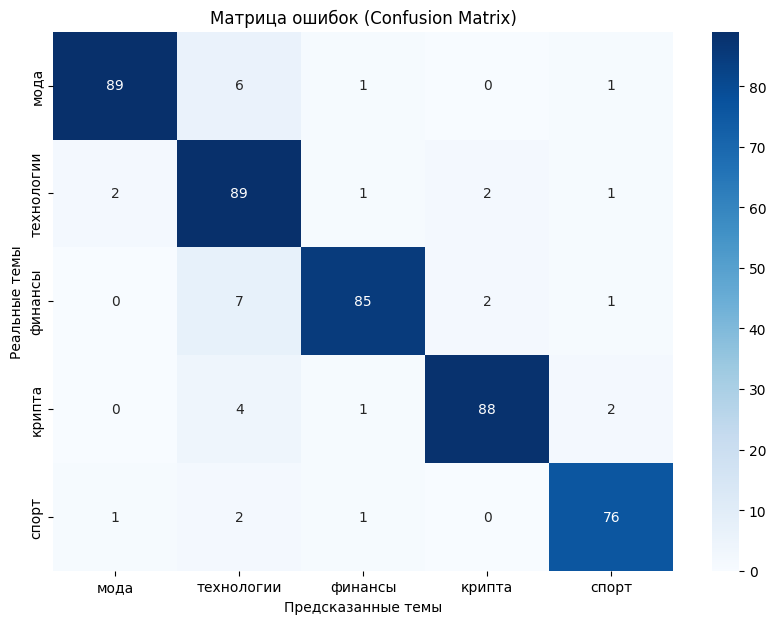

In [392]:
plt.figure(figsize=(10, 7))
cm = confusion_matrix(y_valid_lr, y_pred_val)

# Используем названия тем из вашего маппинга для подписей осей
# Убедитесь, что порядок в списке совпадает с цифрами 0, 1, 2, 3, 4 в mapping
labels = ['мода', 'технологии', 'финансы', 'крипта', 'спорт'] 

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)

plt.title('Матрица ошибок (Confusion Matrix)')
plt.ylabel('Реальные темы')
plt.xlabel('Предсказанные темы')
plt.show()

In [393]:
y_pred_test = model_logreg.predict(X_test_tfidf)

# Смотрим результат
print(f"Accuracy на тесте: {accuracy_score(y_test_lr, y_pred_test):.4f}")
print("\nОтчет по классам:")

print(classification_report(y_test_lr, y_pred_test))
accuracy_logreg_test = accuracy_score(y_test_lr, y_pred_test)
macro_f1_logreg_test = f1_score(y_test_lr, y_pred_test, average='macro')
macro_f1_weighted_test = f1_score(y_test_lr, y_pred_test, average='weighted')

Accuracy на тесте: 0.9320

Отчет по классам:
              precision    recall  f1-score   support

           0       0.98      0.94      0.96        52
           1       0.83      0.94      0.88        52
           2       0.96      0.92      0.94        51
           3       1.00      0.92      0.96        51
           4       0.91      0.93      0.92        44

    accuracy                           0.93       250
   macro avg       0.94      0.93      0.93       250
weighted avg       0.94      0.93      0.93       250



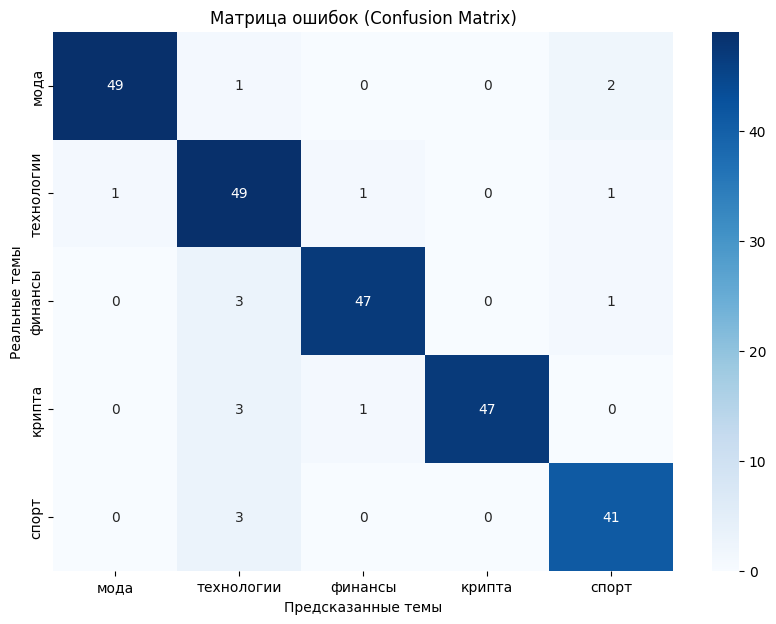

In [394]:
plt.figure(figsize=(10, 7))
cm = confusion_matrix(y_test_lr, y_pred_test)

# Используем названия тем из вашего маппинга для подписей осей
# Убедитесь, что порядок в списке совпадает с цифрами 0, 1, 2, 3, 4 в mapping
labels = ['мода', 'технологии', 'финансы', 'крипта', 'спорт'] 

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)

plt.title('Матрица ошибок (Confusion Matrix)')
plt.ylabel('Реальные темы')
plt.xlabel('Предсказанные темы')
plt.show()

In [395]:
result_all = {}
result_all['logreg_valid'] = {
    'accuracy': accuracy_logreg_valid,
    'f1_macro': macro_f1_logreg_valid,
    'f1_weighted': macro_f1_weighted_valid
}
result_all['logreg_test'] = {
    'accuracy': accuracy_logreg_test,
    'f1_macro': macro_f1_logreg_test,
    'f1_weighted': macro_f1_weighted_test
}

In [396]:
result_all

{'logreg_valid': {'accuracy': 0.9242424242424242,
  'f1_macro': 0.9255670250775638,
  'f1_weighted': 0.9250355933164738},
 'logreg_test': {'accuracy': 0.932,
  'f1_macro': 0.9328398369369004,
  'f1_weighted': 0.9330735496530831}}

In [397]:
# from sklearn.ensemble import RandomForestClassifier

# rf = RandomForestClassifier(n_estimators=300, max_depth=20, random_state=42)
# rf.fit(X_train_tfidf, y_train)

In [398]:
# y_pred_valid_rf =rf.predict(X_valid_tfidf)
# print(f"ИТОГОВАЯ Accuracy на ТЕСТЕ: {accuracy_score(y_valid, y_pred_valid_rf):.4f}")

In [399]:
# y_pred_test_rf = rf.predict(X_test_tfidf)
# print(f"ИТОГОВАЯ Accuracy на ТЕСТЕ: {accuracy_score(y_test, y_pred_test_rf):.4f}")

Отличный показатель логистической регрессии на baseline

### LSTM

готовим данные

In [ ]:
# def clean_lstm(text):
#     # 1. Базовая очистка
#     text = re.sub(r'https?://\S+|t\.me/\S+', ' ', text)
#     text = re.sub(r'@\S+', ' ', text)
#     text = re.sub(r'[^а-яА-Яa-zA-Z\s]', ' ', text)
#     text = text.lower().strip()

#     tokens = []
#     for word in text.split():
#         # Лемматизация
#         normal_form = morph.parse(word)[0].normal_form
        
#         # Убираем стоп-слова и короткие токены
#         if normal_form not in stop_words and len(normal_form) > 2:
#             tokens.append(normal_form)

#     return " ".join(tokens) 

In [ ]:
# def clean_lstm(text):
#     # 1. Удаляем ссылки и упоминания (это шум)
#     text = re.sub(r'https?://\S+|t\.me/\S+', ' ', text)
#     text = re.sub(r'@\S+', ' ', text)
    
#     # 2. Оставляем только буквы и базовую пунктуацию (опционально)
#     # Убираем цифры и спецсимволы, но оставляем пробелы
#     text = re.sub(r'[^а-яА-Яa-zA-Z\s]', ' ', text)
    
#     # 3. Приводим к нижнему регистру и убираем лишние пробелы
#     text = text.lower().strip()
    
#     # 4. Токенизация без жесткой фильтрации
#     tokens = text.split()
    
#     # РЕКОМЕНДАЦИЯ: 
#     # - Не удаляй стоп-слова (они важны для структуры предложения в LSTM)
#     # - Не используй лемматизацию (лучше оставить слова как есть, чтобы модель видела падежи/числа)
#     # - Ограничимся только фильтром совсем короткого мусора (1-2 символа, если это не предлоги)
    
#     clean_tokens = [word for word in tokens if len(word) > 1]
    
#     return " ".join(clean_tokens)

In [ ]:
def clean_lstm(text):
    text = re.sub(r'https?://\S+|t\.me/\S+', ' ', text)
    text = re.sub(r'@\S+', ' ', text)
    text = re.sub(r'[^а-яА-Яa-zA-Z\s]', ' ', text)
    text = text.lower().strip()
    
    # Лемматизируем, но НЕ выкидываем стоп-слова
    tokens = [morph.parse(word)[0].normal_form for word in text.split()]
    # Убираем только совсем мусор (одиночные буквы, кроме 'я', 'и', 'в' и т.д., если хочешь)
    tokens = [t for t in tokens if len(t) > 1 or t in ['я', 'и', 'в', 'не', 'на']]
    
    return " ".join(tokens)

In [1442]:
import re

def clean_text(t):
    if not isinstance(t, str):
        return ""

    # удалить HTML
    t = re.sub(r"<.*?>", " ", t)

    # удалить ссылки
    t = re.sub(r"http\S+|www\.\S+", " ", t)

    # удалить юзернеймы
    t = re.sub(r"@\w+", " ", t)

    # удалить timestamps
    t = re.sub(r"\b\d{1,2}:\d{2}\b", " ", t)

    # удалить даты (простые форматы)
    t = re.sub(r"\b\d{4}-\d{2}-\d{2}\b", " ", t)

    # удалить маркдауны
    t = re.sub(r"[*_`~]", " ", t)

    # обозначения вложений
    t = re.sub(r"\[(photo|video|voice|sticker|gif|file)\]", " ", t)

    # оставить только буквы/цифры/точки/запятые
    t = re.sub(r"[^a-zA-Zа-яА-Я]", " ", t)

    # схлопнуть пробелы
    t = re.sub(r"\s+", " ", t).strip()

    return t

In [1724]:
def clean_lstm(text):
    
    morph = MorphAnalyzer()
    
    # Удаляем шум
    text = re.sub(r'https?://\S+|t\.me/\S+', ' ', text)
    text = re.sub(r'@\w+', ' ', text)
    
    # Оставляем: буквы, цифры, хэштеги, эмодзи, базовую пунктуацию
    # \U0001F300-\U0001F9FF — диапазон популярных эмодзи
    text = re.sub(r'[^\w\s#а-яА-ЯA-Za-z0-9!?.,:;()\-\U0001F300-\U0001F9FF]', ' ', text)
    
    text = text.lower()
    
    tokens = []
    for word in text.split():
        if word.startswith('#'):  # хэштеги как есть
            tokens.append(word)
            continue
        
        try:
            lemma = morph.parse(word)[0].normal_form
            if len(lemma) >= 2:
                tokens.append(lemma)
        except:
            continue
    
    return " ".join(tokens)

In [2128]:
def clean_lstm(text):
    # Удаляем только явный шум
    text = re.sub(r'https?://\S+|t\.me/\S+', ' ', text)
    text = re.sub(r'@\w+', ' ', text)
    
    # ОСТАВЛЯЕМ ВСЁ: цифры, знаки, эмодзи, хэштеги
    text = re.sub(r'[^\w\s#а-яА-ЯA-Za-z0-9]', ' ', text)
    
    text = text.lower()
    
    # Лемматизация
    tokens = []
    for word in text.split():
        if word.startswith('#'):
            tokens.append(word)
            continue
        try:
            lemma = morph.parse(word)[0].normal_form
            if len(lemma) >= 2:
                tokens.append(lemma)
        except:
            continue
    
    return " ".join(tokens)

In [2129]:
df['cleaned_content_lstm'] = df['content'].progress_apply(clean_lstm)

100%|██████████| 2813/2813 [00:13<00:00, 210.41it/s]


In [2130]:
df[df['cleaned_content_lstm'].str.strip() == '']

,url,date,content,label,cleaned_content,label_num,cleaned_content_lstm,Review len


In [2131]:
print(f"Пустых/мусорных: {(df['cleaned_content_lstm'].str.findall(r'[а-яА-Яa-zA-Z0-9]').str.len() < 3).sum()} из {len(df)}")

Пустых/мусорных: 0 из 2813


In [2132]:
df[df['cleaned_content_lstm'].str.findall(r'[а-яА-Яa-zA-Z0-9]').str.len() < 3]

,url,date,content,label,cleaned_content,label_num,cleaned_content_lstm,Review len


In [2133]:
df['content']

0       Широкие бедра всегда считались роскошью и прид...
1       Не знаю как у вас, но у меня ни одна осень не ...
2       Осенью настроение немножко ухудшается. Этому с...
3       Кардиган очень коварен в стилизации, поэтому е...
4       Трикотажные костюмы часто ассоциируются с брюк...
                              ...                        
2895    Mastercard планирует создать магазин для блокч...
2896    Hang Seng Investment Management рассматривает ...
2897    Аналитик Bloomberg оценил шансы BlackRock на з...
2898    Профессия блокчейн-разработчика✏️ ♾ Блокчейн-п...
2899    XRP демонстрирует бычьи сигналы, аналитик пред...
Name: content, Length: 2813, dtype: str

In [2289]:
corpus = [word for text in df['cleaned_content_lstm'] for word in text.split()]
count_words = Counter(corpus)

sorted_words = count_words.most_common()

In [2290]:
print(len(sorted_words))

22740


In [2291]:
def get_words_by_freq(sorted_words: list, n: int = 10) -> list:
    return list(filter(lambda x: x[1] > n, sorted_words))

In [2292]:
print(len(sorted_words))

22740


In [2293]:
sorted_words = get_words_by_freq(sorted_words,1)

In [2294]:
print(len(sorted_words))

11733


In [2295]:
vocab_to_int = {w:i+1 for i, (w,c) in enumerate(sorted_words)}

In [2296]:
reviews_int = []
for text in df['cleaned_content_lstm']:

    r = [vocab_to_int[word] for word in text.split() if vocab_to_int.get(word)]
    reviews_int.append(r)

In [2297]:
print([i for i in reviews_int[99]])

[39, 11, 72, 841, 97, 2281, 36, 1055, 16, 537, 2890, 2890, 1550, 318, 1414, 1144, 2281, 5, 1555, 1219, 35, 1375, 34, 1413, 3090]


In [2298]:
df = df[df['Review len'] >= 2].copy()

In [2299]:
review_len = [len(x) for x in reviews_int]
df['Review len'] = review_len
df.head()

,url,date,content,label,cleaned_content,label_num,cleaned_content_lstm,Review len
0,https://t.me/s/russianmoda/5961,2023-09-17 17:09:06+00:00,Широкие бедра всегда считались роскошью и прид...,мода,широкий бедро считаться роскошь придавать похо...,0,широкий бедро всегда считаться роскошь придава...,40
1,https://t.me/s/russianmoda/5957,2023-09-17 12:09:06+00:00,"Не знаю как у вас, но у меня ни одна осень не ...",мода,знать один осень обходиться кожаный куртка сез...,0,не знать как вы но ни один осень не обходиться...,29
2,https://t.me/s/russianmoda/5951,2023-09-17 06:09:06+00:00,Осенью настроение немножко ухудшается. Этому с...,мода,осень настроение немножко ухудшаться этот спос...,0,осень настроение немножко ухудшаться этот спос...,66
3,https://t.me/s/russianmoda/5939,2023-09-16 17:09:06+00:00,"Кардиган очень коварен в стилизации, поэтому е...",мода,кардиган очень коварный стилизация поэтому нез...,0,кардиган очень коварный стилизация поэтому он ...,22
4,https://t.me/s/russianmoda/5935,2023-09-16 12:09:06+00:00,Трикотажные костюмы часто ассоциируются с брюк...,мода,трикотажный костюм часто ассоциироваться брюки...,0,трикотажный костюм часто ассоциироваться брюки...,38


In [2300]:
print(df['Review len'].describe())

count    2813.000000
mean       77.096338
std        78.156186
min         3.000000
25%        23.000000
50%        49.000000
75%       109.000000
max       547.000000
Name: Review len, dtype: float64


In [2301]:
def padding(review_int: list, seq_len: int) -> np.array:
    """Make left-sided padding for input list of tokens

    Args:
        review_int (list): input list of tokens
        seq_len (int): max length of sequence, it len(review_int[i]) > seq_len it will be trimmed, else it will be padded by zeros

    Returns:
        np.array: padded sequences
    """    
    features = np.zeros((len(reviews_int), seq_len), dtype = int)
    for i, review in enumerate(review_int):
        if len(review) <= seq_len:
            zeros = list(np.zeros(seq_len - len(review)))
            new = zeros + review
        else:
            new = review[: seq_len] # брали начало
            # new = review[-seq_len:]
        features[i, :] = np.array(new)
            
    return features

In [2302]:
SEQ_LEN = 100
features = padding(reviews_int, SEQ_LEN)
print(features[3, :])

[   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0 1957   57 3593  229   16  209
  819    9 1107    3  734    9  416 3085  690  303  363  888 3593 1957
 3594 6734]


In [2303]:
X_train_lstm, X_valid_lstm, y_train_lstm, y_valid_lstm = train_test_split(features, df['label_num'].to_numpy(), test_size=0.25, random_state=42, stratify=df['label_num'])
X_valid_lstm, X_test_lstm, y_valid_lstm, y_test_lstm = train_test_split(X_valid_lstm, y_valid_lstm, test_size=0.2, random_state=42, stratify=y_valid_lstm)
print(f"Обучение (Train): {len(X_train_lstm)} строк")
print(f"Валидация (Val):   {len(X_valid_lstm)} строк")
print(f"Тест (Test):       {len(X_test_lstm)} строк")

Обучение (Train): 2109 строк
Валидация (Val):   563 строк
Тест (Test):       141 строк


In [2304]:
train_data = TensorDataset(torch.from_numpy(X_train_lstm), torch.from_numpy(y_train_lstm))
valid_data = TensorDataset(torch.from_numpy(X_valid_lstm), torch.from_numpy(y_valid_lstm))
test_data = TensorDataset(torch.from_numpy(X_test_lstm), torch.from_numpy(y_test_lstm))


BATCH_SIZE = 64

train_loader = DataLoader(train_data, shuffle=True, batch_size=BATCH_SIZE, drop_last=True)
valid_loader = DataLoader(valid_data, shuffle=True, batch_size=BATCH_SIZE, drop_last=True)
test_loader = DataLoader(test_data, shuffle=True, batch_size=BATCH_SIZE, drop_last=True)

In [2305]:
VOCAB_SIZE = len(vocab_to_int)+1 

In [2306]:
dataiter = iter(train_loader)
sample_x, sample_y = next(dataiter)

In [2307]:
device='cuda' if torch.cuda.is_available() else 'cpu'

In [2308]:
print(X_train)
print(y_train)

1591    человек глупый нейронка распознать объект очев...
421     клип кайлить миноуга отдельный вид искусство в...
1811    калифорния подать суд крупный нефтяной компани...
1437    роботакси cruise остин личный опыт вчера прока...
1666    текст видео уметь ведьма блер качество выше пр...
                              ...                        
569     съёмка такой милый розочка пояс тренч получить...
706     россиянин магомед победить украинец блесецкий ...
1503    авторский право распространяться произведение ...
2258    важный момент думать говорить прошлое экстренн...
684     тоттенхэма гореть выиграть самый поздний камбэ...
Name: cleaned_content, Length: 2135, dtype: str
1591    1
421     0
1811    2
1437    1
1666    1
       ..
569     0
706     4
1503    1
2258    2
684     4
Name: label_num, Length: 2135, dtype: int64


In [2309]:
print('Sample input size: BATCH_SIZE x SEQ_LEN', sample_x.size()) # batch_size, seq_length
print('Sample input: \n', sample_x)
print('Sample input: \n', sample_y)

Sample input size: BATCH_SIZE x SEQ_LEN torch.Size([64, 100])
Sample input: 
 tensor([[   0,    0,    0,  ..., 8210, 6639, 8210],
        [   0,    0,    0,  ...,  938, 3978, 8861],
        [   0,    0,    0,  ..., 5808,  426,   59],
        ...,
        [   7,   82,  106,  ...,  662,  777,   67],
        [   0,    0,    0,  ...,  441,   38, 9642],
        [ 734, 2303,  465,  ...,    1,  774,  375]])
Sample input: 
 tensor([3, 0, 0, 1, 0, 0, 4, 3, 4, 4, 4, 3, 2, 3, 0, 0, 2, 4, 3, 3, 3, 2, 1, 0,
        1, 4, 1, 3, 1, 0, 0, 3, 1, 2, 2, 3, 4, 1, 3, 0, 2, 4, 3, 0, 1, 2, 0, 1,
        0, 0, 3, 4, 0, 2, 2, 1, 1, 2, 0, 2, 0, 2, 1, 0])


In [2310]:
@dataclass
class ConfigRNN:
    vocab_size: int
    device: str
    n_layers: int
    embedding_dim: int
    hidden_size: int
    seq_len: int
    bidirectional: Union[bool, int]
    use_mlflow: bool
    experiment_name: str
    batch_size: int
    epochs: int

In [2311]:
hidden_size = 32
embedding_size = 64
n_layers = 2
n_epochs = 10
mlflow_experiment_name = 'NLP-TG-NEWS'

net_config = ConfigRNN(
    vocab_size=len(vocab_to_int) + 1,
    device='cuda' if torch.cuda.is_available() else 'cpu',
    n_layers=n_layers,
    embedding_dim=embedding_size,
    hidden_size=hidden_size,
    seq_len=SEQ_LEN,
    bidirectional=False,
    use_mlflow=True,
    experiment_name=mlflow_experiment_name,
    batch_size=BATCH_SIZE,
    epochs=n_epochs
)
net_config

ConfigRNN(vocab_size=11734, device='cuda', n_layers=2, embedding_dim=64, hidden_size=32, seq_len=100, bidirectional=False, use_mlflow=True, experiment_name='NLP-TG-NEWS', batch_size=64, epochs=10)

In [2312]:
# class LSTMClassifierO(nn.Module):
#     def __init__(self, rnn_conf=net_config) -> None:
#         super().__init__()

#         self.embedding_dim = rnn_conf.embedding_dim

#         self.hidden_size = rnn_conf.hidden_size
#         self.bidirectional = rnn_conf.bidirectional
#         self.n_layers = rnn_conf.n_layers

#         self.embedding = nn.Embedding(rnn_conf.vocab_size, self.embedding_dim)
#         # self.embedding.weight.requires_grad = False
#         self.lstm = nn.LSTM(
#             input_size=self.embedding_dim,
#             hidden_size=self.hidden_size,
#             bidirectional=self.bidirectional,
#             batch_first=True,
#             num_layers=self.n_layers,
#             dropout=0.3 if self.n_layers > 1 else 0,
#         )
#         self.bidirect_factor = 2 if self.bidirectional else 1

#         self.post_lstm_dropout = nn.Dropout(0.4)        

#         self.clf = nn.Sequential(
#             # nn.Linear(self.hidden_size * self.bidirect_factor, 128),
#             nn.Linear(self.hidden_size * self.bidirect_factor * 2, 64) ,
#             # nn.BatchNorm1d(64),
#             nn.LayerNorm(64),
#             # nn.LeakyReLU(),  
#             # nn.Dropout(0.75),

#             # nn.Tanh(),
#             nn.LeakyReLU(),
#             nn.Dropout(0.4),

#             nn.Linear(64, 32),

#             # nn.BatchNorm1d(32),
#             # nn.LeakyReLU(),  
#             # nn.Dropout(0.75),

#             # nn.Tanh(),
#             nn.LeakyReLU(),
#             nn.Dropout(0.6),

#             nn.Linear(32, 5)
#         )

#     def model_description(self):
#         direction = "bidirect" if self.bidirectional else "onedirect"
#         return f"lstm_{direction}_{self.n_layers}"

#     def forward(self, x: torch.Tensor):
#         embeddings = self.embedding(x)
#         out, _ = self.lstm(embeddings)
#         # print(out.shape)
#         # out = out[:, -1, :]  # [все элементы батча, последний h_n, все элементы последнего h_n]
#         # out = torch.mean(out, dim=1) 

#         avg_p = torch.mean(out, dim=1)
#         max_p, _ = torch.max(out, dim=1)
#         out = torch.cat([avg_p, max_p], dim=1)

#         out = self.post_lstm_dropout(out)        
#         # print(out.shape)
#         out = self.clf(out)
#         # print(out.shape)
#         return out

In [2313]:
class LSTMClassifierO(nn.Module):
    def __init__(self, rnn_conf) -> None:
        super().__init__()
        
        self.embedding_dim = rnn_conf.embedding_dim
        self.hidden_size = rnn_conf.hidden_size
        self.bidirectional = rnn_conf.bidirectional
        self.n_layers = rnn_conf.n_layers
        
        self.embedding = nn.Embedding(rnn_conf.vocab_size, self.embedding_dim, padding_idx=0)
        
        self.lstm = nn.LSTM(
            input_size=self.embedding_dim,
            hidden_size=self.hidden_size,
            bidirectional=self.bidirectional,
            batch_first=True,
            num_layers=self.n_layers,
            dropout=0.5 if self.n_layers > 1 else 0, # Снижен до 0.2
        )
        
        self.bidirect_factor = 2 if self.bidirectional else 1
        # Вход в классификатор: hidden * factor * 2 (так как мы конкатенируем avg и max)
        self.clf_input_dim = self.hidden_size * self.bidirect_factor * 2
        
        # self.clf = nn.Sequential(
        #     nn.Linear(self.clf_input_dim, 128),
        #     nn.BatchNorm1d(128),
        #     nn.ReLU(),
        #     nn.Dropout(0.5), # Увеличиваем здесь, чтобы заставить модель учиться сложнее

        #     nn.Linear(128, 5) # Сразу в 5 классов, меньше промежуточных слоев — меньше переобучения
        # )

        self.clf = nn.Sequential(
            nn.Linear(self.clf_input_dim, self.hidden_size * self.bidirect_factor), # Динамический размер
            nn.ReLU(),
            nn.Dropout(0.2), # Достаточно для регуляризации
            nn.Linear(self.hidden_size * self.bidirect_factor, 5)
)
        
        self._init_weights()

    def _init_weights(self):
        # Инициализация Кайминга для линейных слоев помогает избежать "затухания" на старте
        for m in self.clf:
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight)
                nn.init.constant_(m.bias, 0)

    def forward(self, x: torch.Tensor):
        # x: [batch, seq_len]
        embeddings = self.embedding(x) # [batch, seq_len, emb_dim]
        
        # LSTM output: [batch, seq_len, hidden * direction]
        out, _ = self.lstm(embeddings)
        
        # Global Pooling (Average + Max) — хорошо работает для текстов разной длины
        avg_p = torch.mean(out, dim=1)
        max_p, _ = torch.max(out, dim=1)
        
        combined = torch.cat([avg_p, max_p], dim=1) # [batch, hidden * factor * 2]
        
        return self.clf(combined)

In [2314]:
class LSTMClassifier0(nn.Module):
    def __init__(self, rnn_conf) -> None:
        super().__init__()
        
        self.embedding_dim = rnn_conf.embedding_dim
        self.hidden_size = rnn_conf.hidden_size
        self.bidirectional = rnn_conf.bidirectional
        self.n_layers = rnn_conf.n_layers
        
        self.embedding = nn.Embedding(rnn_conf.vocab_size, self.embedding_dim, padding_idx=0)
        
        self.lstm = nn.LSTM(
            input_size=self.embedding_dim,
            hidden_size=self.hidden_size,
            bidirectional=self.bidirectional,
            batch_first=True,
            num_layers=self.n_layers,
            dropout=0.5 if self.n_layers > 1 else 0,
        )
        
        self.bidirect_factor = 2 if self.bidirectional else 1
        self.clf_input_dim = self.hidden_size * self.bidirect_factor * 2
        
        self.clf = nn.Sequential(
            nn.Linear(self.clf_input_dim, self.hidden_size * self.bidirect_factor),
            nn.LayerNorm(self.hidden_size * self.bidirect_factor),
            nn.ReLU(),
            nn.Dropout(0.5),  
            nn.Linear(self.hidden_size * self.bidirect_factor, 5)
        )

    def forward(self, x: torch.Tensor):
        embeddings = self.embedding(x)
        out, _ = self.lstm(embeddings)
        avg_p = torch.mean(out, dim=1)
        max_p, _ = torch.max(out, dim=1)
        combined = torch.cat([avg_p, max_p], dim=1)
        return self.clf(combined)

In [2315]:
from torchmetrics.classification import MulticlassAccuracy, MulticlassF1Score
import torch.nn as nn

# Создаем метрики
acc_fn = MulticlassAccuracy(num_classes=5, average='micro').to(net_config.device)
f1_fn = MulticlassF1Score(num_classes=5, average='macro').to(net_config.device)

# Объединяем их в словарь для удобства передачи
metrics_dict = {'acc': acc_fn, 'f1': f1_fn}

In [2316]:
# import copy # Для сохранения лучшей модели

# def train(epochs, model, train_loader, valid_loader, optimizer, criterion, device, metrics, rnn_conf=None):
#     result = {
#         'train_loss': [], 'valid_loss': [],
#         'train_acc': [], 'valid_acc': [],
#         'train_f1': [], 'valid_f1': []
#     }
    
#     # --- НОВОЕ: Настройка Scheduler и Early Stopping ---
#     scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
#     best_valid_loss = float('inf')
#     best_model_wts = copy.deepcopy(model.state_dict())
#     patience_counter = 0
#     early_stop_patience = 5 # Остановим через 5 эпох без улучшений
#     # --------------------------------------------------

#     time_start = time()
#     model.to(device)

#     for epoch in range(epochs):
#         # --- TRAINING ---
#         model.train()
#         train_losses = []
#         for inputs, labels in train_loader:
#             inputs, labels = inputs.to(device), labels.to(device).long()
            
#             optimizer.zero_grad()
#             outputs = model(inputs)
#             loss = criterion(outputs, labels)
#             loss.backward()
#             optimizer.step()
            
#             train_losses.append(loss.item())
#             metrics['acc'].update(outputs, labels)
#             metrics['f1'].update(outputs, labels)
        
#         e_train_loss = np.mean(train_losses)
#         e_train_acc = metrics['acc'].compute().item()
#         e_train_f1 = metrics['f1'].compute().item()
#         metrics['acc'].reset(); metrics['f1'].reset()

#         # --- VALIDATION ---
#         model.eval()
#         valid_losses = []
#         with torch.no_grad():
#             for inputs, labels in valid_loader:
#                 inputs, labels = inputs.to(device), labels.to(device).long()
#                 outputs = model(inputs)
#                 loss = criterion(outputs, labels)
#                 valid_losses.append(loss.item())
#                 metrics['acc'].update(outputs, labels)
#                 metrics['f1'].update(outputs, labels)

#         e_valid_loss = np.mean(valid_losses)
#         e_valid_acc = metrics['acc'].compute().item()
#         e_valid_f1 = metrics['f1'].compute().item()
#         metrics['acc'].reset(); metrics['f1'].reset()

#         # --- НОВОЕ: Логика Scheduler и сохранения лучшей модели ---
#         scheduler.step(e_valid_loss) # Снижает LR, если лосс не падает

#         if e_valid_loss < best_valid_loss:
#             best_valid_loss = e_valid_loss
#             best_model_wts = copy.deepcopy(model.state_dict())
#             patience_counter = 0
#             print(f"  --> Найдена лучшая модель (Loss: {e_valid_loss:.4f})")
#         else:
#             patience_counter += 1

#         # Сохранение истории
#         result['train_loss'].append(e_train_loss)
#         result['valid_loss'].append(e_valid_loss)
#         result['train_acc'].append(e_train_acc)
#         result['valid_acc'].append(e_valid_acc)
#         result['train_f1'].append(e_train_f1)
#         result['valid_f1'].append(e_valid_f1)

#         print(f"Epoch {epoch+1}/{epochs} | Loss: {e_train_loss:.3f}/{e_valid_loss:.3f} | Acc: {e_valid_acc:.3f} | F1: {e_valid_f1:.3f}")

#         # Ранняя остановка
#         if patience_counter >= early_stop_patience:
#             print(f"Early stopping на эпохе {epoch+1}")
#             break

#     # Загружаем лучшие веса перед возвратом
#     model.load_state_dict(best_model_wts)
#     return result, time() - time_start

In [2317]:
def train(epochs, model, train_loader, valid_loader, optimizer, criterion, device, metrics, rnn_conf=None):
    result = {
        'train_loss': [], 'valid_loss': [],
        'train_acc': [], 'valid_acc': [],
        'train_f1': [], 'valid_f1': []
    }
    
    # Scheduler оставляем — он полезен для "дожима" точности
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
    
    best_valid_loss = float('inf')
    best_model_wts = copy.deepcopy(model.state_dict())
    
    time_start = time()
    model.to(device)

    for epoch in range(epochs):
        # --- TRAINING ---
        model.train()
        train_losses = []
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device).long()
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_losses.append(loss.item())
            metrics['acc'].update(outputs, labels)
            metrics['f1'].update(outputs, labels)
        
        e_train_loss = np.mean(train_losses)
        e_train_acc = metrics['acc'].compute().item()
        e_train_f1 = metrics['f1'].compute().item()
        metrics['acc'].reset(); metrics['f1'].reset()

        # --- VALIDATION ---
        model.eval()
        valid_losses = []
        with torch.no_grad():
            for inputs, labels in valid_loader:
                inputs, labels = inputs.to(device), labels.to(device).long()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                valid_losses.append(loss.item())
                metrics['acc'].update(outputs, labels)
                metrics['f1'].update(outputs, labels)

        e_valid_loss = np.mean(valid_losses)
        e_valid_acc = metrics['acc'].compute().item()
        e_valid_f1 = metrics['f1'].compute().item()
        metrics['acc'].reset(); metrics['f1'].reset()

        # --- Scheduler и сохранение лучшего состояния ---
        scheduler.step(e_valid_loss) 

        if e_valid_loss < best_valid_loss:
            best_valid_loss = e_valid_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            print(f"  --> Найдена лучшая модель (Loss: {e_valid_loss:.4f})")

        # Сохранение истории
        result['train_loss'].append(e_train_loss)
        result['valid_loss'].append(e_valid_loss)
        result['train_acc'].append(e_train_acc)
        result['valid_acc'].append(e_valid_acc)
        result['train_f1'].append(e_train_f1)
        result['valid_f1'].append(e_valid_f1)

        print(f"Epoch {epoch+1}/{epochs} | Loss: {e_train_loss:.3f}/{e_valid_loss:.3f} | Acc: {e_valid_acc:.3f} | F1: {e_valid_f1:.3f}")

    # Загружаем лучшие веса (от самой удачной эпохи) перед выходом
    model.load_state_dict(best_model_wts)
    print(f"\nОбучение завершено. Лучший Valid Loss: {best_valid_loss:.4f}")
    
    return result, time() - time_start

In [2318]:
from time import time

def run_train_pipeline(model, optimizer, criterion, train_loader, valid_loader, config, device, metric, run_name="Experiment"):
    """
    Обертка над процессом обучения с поддержкой MLflow
    """
    use_mlflow = config.use_mlflow
    
    if use_mlflow:
        mlflow.set_experiment(config.experiment_name)
        
        with mlflow.start_run(run_name=run_name):
            # 1. Логируем параметры
            mlflow.log_params({
                'batch_size': config.batch_size,
                'hidden_size': config.hidden_size,
                'embedding_dim': config.embedding_dim,                
                'seq_len': config.seq_len,                  
                'epochs': config.epochs,
                'device': str(device),

                # 'encoder': getattr(config, 'encoder', 'unknown') # Вместо .get() используй getattr для объектов
            })


            # 2. Запуск обучения
            start_time = time()
            history, training_time = train(
                epochs=config.epochs, 
                model=model, 
                train_loader=train_loader, 
                valid_loader=valid_loader,
                optimizer=optimizer, 
                criterion=criterion,
                device=device,
                metrics=metric,
                rnn_conf=config
            )
            end_time = time()
            train_time = end_time - start_time
            mlflow.log_metric('work_time_model', train_time)

            # 3. Логируем модель (с учетом ворнинга используем 'name')
            mlflow.pytorch.log_model(model, name='model_rnn')
            
            return history, train_time
    else:
        # Обычный запуск без MLflow
        return train(
                epochs=config.epochs, 
                model=model, 

                train_loader=train_loader, 
                valid_loader=valid_loader,

                optimizer=optimizer, 
                criterion=criterion,
                device=device,
                metrics=metric,
                rnn_conf=config
            )


In [2329]:
net_config.epochs = 30
net_config.hidden_size = 128 # если было 64
net_config.embedding_dim = 1024 # если было 128
net_config.bidirectional=True
net_config.use_mlflow=False

In [2330]:
model_lstm = LSTMClassifierO(net_config)
tu.get_model_summary(model_lstm, sample_x)

Layer                Kernel           Output          Params               FLOPs
0_embedding       [1024, 11734]   [64, 100, 1024]   12,015,616             6,400
1_lstm                        -    [64, 100, 256]    1,576,960   128,430,899,200
2_clf.Linear_0       [512, 256]         [64, 256]      131,328        16,760,832
3_clf.ReLU_1                  -         [64, 256]            0                 0
4_clf.Dropout_2               -         [64, 256]            0                 0
5_clf.Linear_3         [256, 5]           [64, 5]        1,285           163,520
Total params: 13,725,189
Trainable params: 13,725,189
Non-trainable params: 0
Total FLOPs: 128,447,829,952 / 128.45 GFLOPs
--------------------------------------------------------------------------------
Input size (MB): 0.05
Forward/backward pass size (MB): 62.88
Params size (MB): 52.36
Estimated Total Size (MB): 115.28


In [2331]:
# net_config.epochs = 30
# net_config.hidden_size = 128 # если было 64
# net_config.embedding_dim = 64 # если было 128
# net_config.bidirectional=True

In [2332]:
net_config

ConfigRNN(vocab_size=11734, device='cuda', n_layers=2, embedding_dim=1024, hidden_size=128, seq_len=100, bidirectional=True, use_mlflow=False, experiment_name='NLP-TG-NEWS', batch_size=64, epochs=30)

In [2333]:
from torchmetrics.classification import MulticlassAccuracy, MulticlassF1Score
import torch.nn as nn

# Создаем метрики
acc_fn = MulticlassAccuracy(num_classes=5, average='micro').to(net_config.device)
f1_fn = MulticlassF1Score(num_classes=5, average='macro').to(net_config.device)

# Объединяем их в словарь для удобства передачи
metrics_dict = {'acc': acc_fn, 'f1': f1_fn}

In [2334]:
optimizer_lstm = torch.optim.AdamW(
    model_lstm.parameters(), 
    lr=0.0005,        
    weight_decay=0.001
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_lstm, mode='min', factor=0.5, patience=3
)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
# Запуск
history, total_time = run_train_pipeline(
    model=model_lstm,
    optimizer=optimizer_lstm,
    criterion=criterion,
    train_loader=train_loader,
    valid_loader=valid_loader,
    config=net_config,
    device=net_config.device,
    metric=metrics_dict, # Передаем словарь метрик
    run_name='LSTM_Final_Run'
)

  --> Найдена лучшая модель (Loss: 1.4040)
Epoch 1/30 | Loss: 1.532/1.404 | Acc: 0.477 | F1: 0.415
  --> Найдена лучшая модель (Loss: 0.9688)
Epoch 2/30 | Loss: 1.165/0.969 | Acc: 0.740 | F1: 0.738
  --> Найдена лучшая модель (Loss: 0.7158)
Epoch 3/30 | Loss: 0.712/0.716 | Acc: 0.869 | F1: 0.870
  --> Найдена лучшая модель (Loss: 0.6621)
Epoch 4/30 | Loss: 0.507/0.662 | Acc: 0.889 | F1: 0.890
  --> Найдена лучшая модель (Loss: 0.6358)
Epoch 5/30 | Loss: 0.439/0.636 | Acc: 0.891 | F1: 0.892
  --> Найдена лучшая модель (Loss: 0.6301)
Epoch 6/30 | Loss: 0.417/0.630 | Acc: 0.896 | F1: 0.897
Epoch 7/30 | Loss: 0.409/0.632 | Acc: 0.893 | F1: 0.893
  --> Найдена лучшая модель (Loss: 0.6273)
Epoch 8/30 | Loss: 0.405/0.627 | Acc: 0.893 | F1: 0.893
Epoch 9/30 | Loss: 0.403/0.632 | Acc: 0.896 | F1: 0.898
Epoch 10/30 | Loss: 0.401/0.633 | Acc: 0.887 | F1: 0.887
Epoch 11/30 | Loss: 0.400/0.637 | Acc: 0.885 | F1: 0.886
  --> Найдена лучшая модель (Loss: 0.6260)
Epoch 12/30 | Loss: 0.399/0.626 | Acc:

In [2335]:
result_all['lstm_valid'] = history

In [2336]:
history.keys()

dict_keys(['train_loss', 'valid_loss', 'train_acc', 'valid_acc', 'train_f1', 'valid_f1'])

Text(0.5, 1.0, 'F1')

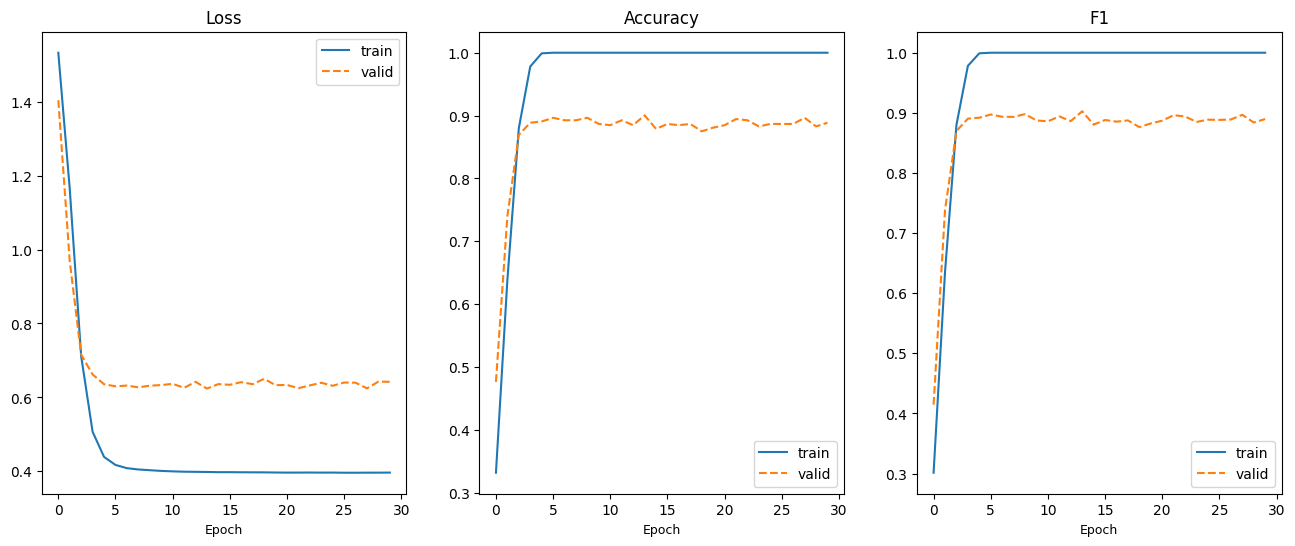

In [2337]:
fig = plt.figure(figsize=(16, 6))
ax1 = plt.subplot2grid((1,3), (0,0))
ax1.plot(result_all['lstm_valid']['train_loss'], label='train')
ax1.plot(result_all['lstm_valid']['valid_loss'], linestyle='--', label='valid')
ax1.set_xlabel('Epoch', fontsize=9)
ax1.legend()
ax1.set_title(f'Loss')

ax1 = plt.subplot2grid((1,3), (0,1))
ax1.plot(result_all['lstm_valid']['train_acc'], label='train')
ax1.plot(result_all['lstm_valid']['valid_acc'], linestyle='--', label='valid')
ax1.set_xlabel('Epoch', fontsize=9)
ax1.legend()
ax1.set_title(f'Accuracy')

ax1 = plt.subplot2grid((1,3), (0,2))
ax1.plot(result_all['lstm_valid']['train_f1'], label='train')
ax1.plot(result_all['lstm_valid']['valid_f1'], linestyle='--', label='valid')
ax1.set_xlabel('Epoch', fontsize=9)
ax1.legend()
ax1.set_title(f'F1')

Accuracy: 0.8945 (89.45%)
F1 Macro: 0.8961

Classification Report:
              precision    recall  f1-score   support

           0     0.8462    0.9252    0.8839       107
           1     0.8558    0.8396    0.8476       106
           2     0.9020    0.8762    0.8889       105
           3     0.9579    0.8750    0.9146       104
           4     0.9255    0.9667    0.9457        90

    accuracy                         0.8945       512
   macro avg     0.8975    0.8965    0.8961       512
weighted avg     0.8962    0.8945    0.8945       512


Confusion Matrix:
[[99  4  1  0  3]
 [12 89  1  2  2]
 [ 3  7 92  2  1]
 [ 2  4  6 91  1]
 [ 1  0  2  0 87]]


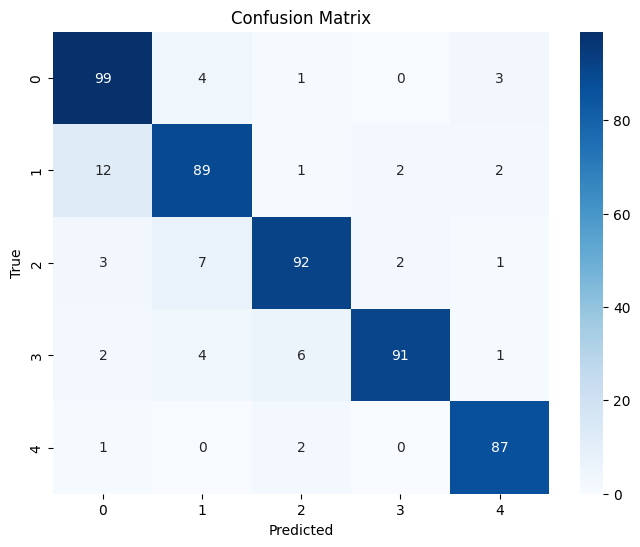

In [2338]:
model_lstm.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in valid_loader:
        x, y = batch[0].to(net_config.device), batch[1].to(net_config.device)
        outputs = model_lstm(x)
        preds = torch.argmax(outputs, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

# ==================== МЕТРИКИ ====================

accuracy = accuracy_score(all_labels, all_preds)
f1_macro = f1_score(all_labels, all_preds, average='macro')

print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"F1 Macro: {f1_macro:.4f}")

# ==================== CLASSIFICATION REPORT ====================

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, digits=4))

# ==================== CONFUSION MATRIX ====================

cm = confusion_matrix(all_labels, all_preds)
print("\nConfusion Matrix:")
print(cm)

# ==================== ВИЗУАЛИЗАЦИЯ (опционально) ====================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

### BERT